# PyTorch model

In [1]:
import os
import torch
import sys
from torch import nn
# import lightning as L
import pandas as pd
import xarray as xr
import csv
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
# from brokenaxes import brokenaxes
import warnings 
import tqdm
warnings.filterwarnings("ignore")

In [3]:
from simspice.data.SproutDataset_SO import SproutDataset
from torch.utils.data import DataLoader
from simspice.utils.Augmentation import Augmentation
from simspice.data.Sprout_ML_SO import Sprout_ML, interpolate_arrays

In [4]:
import wandb

In [5]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.device(0))
torch.cuda.get_device_name(0)
torch.cuda.set_device(2)

True
4


In [6]:
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [7]:
len([783.47119081, 783.66622481, 783.86125881,
    784.05629281, 784.25132681, 784.44636081,
    784.64139481, 784.83642881, 785.03146281,
    785.22649681, 785.42153081, 785.61656481,
    785.81159881, 786.00663281, 786.20166681,
    786.39670081, 786.59173481, 786.78676881,
    786.98180281, 787.17683681, 787.37187081,
    787.56690481, 787.76193881, 787.95697281,
    788.15200681, 788.34704081, 788.54207481,
    788.73710881])

28

### Write to netcdf format 

In [8]:
def write_files_to_netcdf(directory, netcdf_file, nbr_files=None):
    all_flux = []
    all_mask = []
    all_k = []
    all_l = []
    index = []
    filenames = []
    
    i = 0
    for filename in tqdm.tqdm(os.listdir(directory)[:nbr_files]):
        if os.path.isfile(os.path.join(directory, filename)):
            file = Sprout_ML(directory, filename)
            wvl_common = file.common_wvl
            
            #################################
            padded_spectra, masks = file.pad_flux_array(method='zeros')  # get padded flux arrays and masks
            wvl_arrays_padded = file.pad_wvl_arrays()
            full_spectra = np.vstack(padded_spectra)  # combine spectra into a single array
            full_mask = np.vstack(masks)  # combine masks
            full_wvl = np.hstack(wvl_arrays_padded)
            print("full_wvl shape:", full_wvl.shape)
            print("full_spectra shape:", full_spectra.shape)
            print("full_mask shape:", full_mask.shape)

            for k in range(full_spectra.shape[1]):
                for l in range(full_spectra.shape[2]):
                    spec_common_wvl, mask_common_wvl = interpolate_arrays(wvl_common, full_wvl, full_spectra[:, k, l], full_mask[:, k, l])
                    all_flux.append(spec_common_wvl)
                    all_mask.append(mask_common_wvl)
                    all_k.append(k)
                    all_l.append(l)
                    index.append(i)
                    filenames.append(filename)
                    i += 1

    # xarray Dataset
    ds = xr.Dataset(
        {
            "flux": (("index", "wvl"), np.array(all_flux)),
            "mask": (("index", "wvl"), np.array(all_mask)),
            "x-index" : (("index"), all_k),
            "y-index" : (("index"), all_l),
            "filename" : (("index"), filenames),
        },
        coords={"index": index,
                "wvl" : wvl_common, # interp1d array set of wvl every single spectrum is going to be interpolated into.
                }
            )

    # Save to NetCDF
    ds.to_netcdf(netcdf_file)

directory_path = '/d0/tvaresano/SimSPICE/data_L2/'
netcdf_file_path = '/d0/tvaresano/SimSPICE/spectra_train_SO_10files.nc'

write_files_to_netcdf(directory_path, netcdf_file_path, 10)

  0%|          | 0/10 [00:00<?, ?it/s]

full_wvl shape: (48,)
full_spectra shape: (48, 605, 192)
full_mask shape: (48, 605, 192)


 10%|█         | 1/10 [00:07<01:11,  7.98s/it]

full_wvl shape: (48,)
full_spectra shape: (48, 605, 192)
full_mask shape: (48, 605, 192)


 20%|██        | 2/10 [00:15<01:03,  7.95s/it]

...

 80%|████████  | 8/10 [01:03<00:15,  7.97s/it]

full_wvl shape: (48,)
full_spectra shape: (48, 605, 192)
full_mask shape: (48, 605, 192)


 90%|█████████ | 9/10 [01:11<00:07,  7.96s/it]

full_wvl shape: (48,)
full_spectra shape: (48, 605, 192)
full_mask shape: (48, 605, 192)


100%|██████████| 10/10 [01:20<00:00,  8.00s/it]


In [9]:
netcdf_file_path = '/d0/tvaresano/SimSPICE/spectra_Feb2023_SO.nc'
directory_path = '/d0/tvaresano/SimSPICE/data_L2/Feb2023/'
write_files_to_netcdf(directory_path, netcdf_file_path, 1)

  0%|          | 0/1 [00:00<?, ?it/s]

full_wvl shape: (48,)
full_spectra shape: (48, 605, 192)
full_mask shape: (48, 605, 192)


100%|██████████| 1/1 [00:08<00:00,  8.10s/it]


# Test augmentations

In [10]:
import simspice.utils.inverse_mapping_functions as imf

In [11]:
os.getcwd()
os.chdir('/d0/tvaresano/SimSPICE/')

solo_L2_spice-n-ras_20230211T153421_V22_167772557-000.fits
(40, 605, 192)


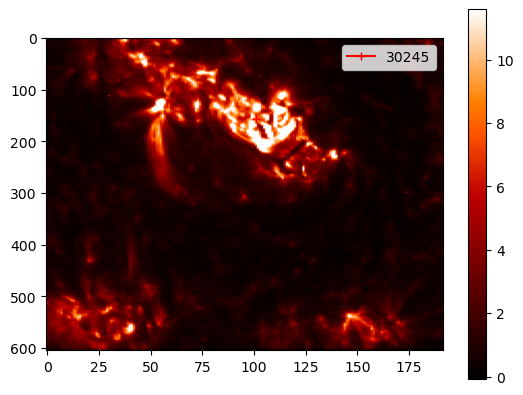

solo_L2_spice-n-ras_20230211T153421_V22_167772557-000.fits
(40, 605, 192)


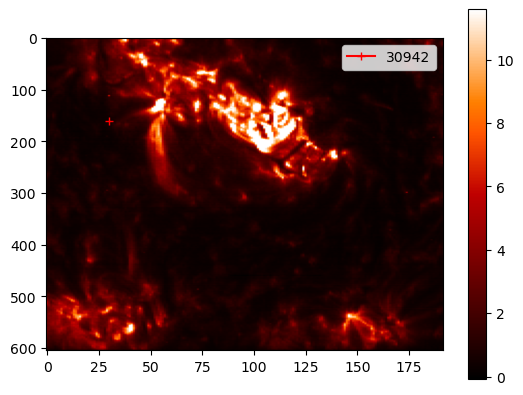

In [12]:
imf.map_item_map(30245,
                 dataset= "spectra_Feb2023_SO.nc",
                 plot=True,
                 data_dir = 'data_L2/Feb2023/')
plt.show()
imf.map_item_map(30942,
                 dataset= "spectra_Feb2023_SO.nc",
                 plot=True,
                 data_dir = 'data_L2/Feb2023/')

In [13]:
all_spectra = xr.open_dataset("/d0/tvaresano/SimSPICE/spectra_Feb2023_SO.nc")
item = all_spectra.isel(index=22575)
item1 = all_spectra.isel(index=30245)

In [14]:
aug = Augmentation(type_distrib_gain='gaussian', shift_range=(-0.04,0.04))
augmented1 = aug.run_all_augmentations(item)[0]
augmented2 = aug.run_all_augmentations(item)[0]

Text(0.5, 1.0, 'S V and O IV')

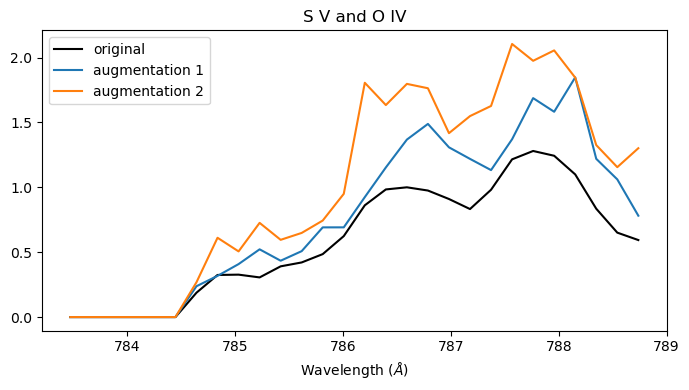

In [15]:
plt.figure(figsize=[7,4], tight_layout=True)
plt.plot(item['wvl'].values, item['flux'].values, label='original', alpha=1, color='k')
plt.plot(item['wvl'].values, augmented1, label='augmentation 1')
plt.plot(item['wvl'].values, augmented2, label='augmentation 2')
plt.xlabel('Wavelength ($\AA$)')
# plt.plot(item['wvl'].values, item1['flux'].values, label='spectrum1', alpha=0.5)
# plt.axhline(np.median(item1['flux'].values))
plt.legend()
plt.title('S V and O IV')